In [1]:
!date

Sat Sep 19 01:02:20 PDT 2026


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, mannwhitneyu
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'

In [3]:
x = pd.read_csv(f'{projdir}/csv/ambisim/droplet_scores_cov.csv', sep='\t')
design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['pool'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('pool')[['pool', 'min_dist', 'mean_dist', 'kl_min']]
x = x.merge(design, on='pool', how='left')
x['grp'] = np.where(x['strategy'].str.startswith('adversarial_family'), 'family',
           np.where(x['strategy'] == 'adversarial_mindist', 'adv_mindist', 'ordinary'))

In [4]:
x.head()

,pool,universe,strategy,rep,modality,barcode,is_true_singlet,called_singlet,correct,donor_correct,...,n_snps,n_reads_demux,true_reads,called_donor,true_donor,heldout,min_dist,mean_dist,kl_min,grp
0,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACAACA,True,True,True,True,...,3232,3391,22915,HG02678,HG02678,False,104.52751,120.43151,1.886853,ordinary
1,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACATAG,True,True,True,True,...,4130,4488,30010,HG02816,HG02816,False,104.52751,120.43151,1.886853,ordinary
2,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCCTA,True,True,True,True,...,2582,2843,19977,NA19922,NA19922,False,104.52751,120.43151,1.886853,ordinary
3,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCTAT,True,True,True,True,...,718,741,5237,NA20274,NA20274,False,104.52751,120.43151,1.886853,ordinary
4,AFR_only__greedy_maxmean__rep1,AFR_only,greedy_maxmean,1,gex,AAACAGCCAAACCTTG,True,True,True,True,...,6682,7458,51490,HG03136,HG03136,False,104.52751,120.43151,1.886853,ordinary


In [5]:
x.shape

(2303744, 25)

In [6]:
### 01e-01g only ever looked at true singlets. the simulation also makes 900 true doublets
### per pool (8100 singlets + 900 doublets), and those were never scored. demuxlet's SNG/DBL
### boundary has two sides and pool design may sit differently on each.
dbl = x[~x['is_true_singlet']].copy()
dbl['called_dbl'] = dbl['droplet_type'] == 'DBL'
print('true doublets per pool x modality:', int(dbl.groupby(['pool', 'modality']).size().mean()))
for mod in ['gex', 'atac']:
    print(f'--- {mod} ---')
    print(dbl[dbl['modality'] == mod].groupby('grp')['called_dbl'].agg(['size', 'mean']).round(4).to_string())

true doublets per pool x modality: 900
--- gex ---
              size    mean
grp                       
adv_mindist  15300  0.9488
family        5400  0.9433
ordinary     94500  0.9590
--- atac ---
              size    mean
grp                       
adv_mindist  15300  0.9948
family        5400  0.9924
ordinary     94500  0.9957


In [7]:
### between pools: does donor geometry change how often a real doublet is caught?
for mod in ['gex', 'atac']:
    t = dbl[dbl['modality'] == mod]
    pp = t.groupby('pool').agg(rate=('called_dbl', 'mean'), min_dist=('min_dist', 'first'),
                               mean_dist=('mean_dist', 'first'), strategy=('strategy', 'first'))
    o = pp[~pp['strategy'].str.startswith('adversarial')]
    adv = pp[pp['strategy'].str.startswith('adversarial')]
    for geo in ['min_dist', 'mean_dist']:
        rho, p = spearmanr(o[geo], o['rate'])
        print(f'{mod}: P(called DBL | true doublet) ~ {geo:10s} ordinary n={len(o)} rho={rho:+.3f} p={p:.4f}')
    u, pu = mannwhitneyu(adv['rate'], o['rate'], alternative='less')
    print(f'      adversarial {adv["rate"].mean():.4f} vs ordinary {o["rate"].mean():.4f} (MWU p={pu:.4f})')

gex: P(called DBL | true doublet) ~ min_dist   ordinary n=105 rho=+0.247 p=0.0109
gex: P(called DBL | true doublet) ~ mean_dist  ordinary n=105 rho=+0.600 p=0.0000
      adversarial 0.9473 vs ordinary 0.9590 (MWU p=0.0002)
atac: P(called DBL | true doublet) ~ min_dist   ordinary n=105 rho=+0.021 p=0.8329
atac: P(called DBL | true doublet) ~ mean_dist  ordinary n=105 rho=+0.437 p=0.0000
      adversarial 0.9942 vs ordinary 0.9957 (MWU p=0.0145)


In [8]:
### the sharper version: rank each droplet's OWN two donors by how far apart they are, within
### its own pool. removes any between-pool confounding -- this is the same pool, same depth,
### same ambient, just a closer or farther pair of donors sharing the droplet.
m = np.load(f'{projdir}/csv/designs/1kg_chr22_dist_matrix.npz', allow_pickle=True)
D, sid = m['D'], list(m['sample_ids'])
pos = {s: i for i, s in enumerate(sid)}
pair = dbl['true_donor'].str.split(',')
dbl['dA'], dbl['dB'] = pair.str[0], pair.str[1]
dbl = dbl[dbl['dA'].isin(pos) & dbl['dB'].isin(pos)].copy()
dbl['pair_dist'] = D[[pos[a] for a in dbl['dA']], [pos[b] for b in dbl['dB']]]
dbl['rk'] = dbl.groupby(['pool', 'modality'])['pair_dist'].rank(pct=True)
dbl['q'] = pd.cut(dbl['rk'], [0, .2, .4, .6, .8, 1.0],
                  labels=['closest 20%', '20-40', '40-60', '60-80', 'farthest 20%'])
within = []
for mod in ['gex', 'atac']:
    g = dbl[dbl['modality'] == mod].groupby('q', observed=True).agg(
        n=('called_dbl', 'size'), called_dbl=('called_dbl', 'mean'),
        pair_dist=('pair_dist', 'mean')).reset_index()
    g['modality'] = mod
    within.append(g)
    print(f'--- {mod} ---')
    print(g.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
within = pd.concat(within, ignore_index=True)

--- gex ---
           q     n  called_dbl  pair_dist modality
 closest 20% 23260      0.9471   105.2203      gex
       20-40 22744      0.9528   109.3762      gex
       40-60 23205      0.9574   112.5010      gex
       60-80 22687      0.9626   115.1090      gex
farthest 20% 23304      0.9645   118.5912      gex
--- atac ---
           q     n  called_dbl  pair_dist modality
 closest 20% 23260      0.9940   105.2203     atac
       20-40 22744      0.9946   109.3762     atac
       40-60 23205      0.9960   112.5010     atac
       60-80 22687      0.9963   115.1090     atac
farthest 20% 23304      0.9960   118.5912     atac


In [9]:
### THE OPERATING POINT. the two sides of the SNG/DBL boundary move in opposite directions
### with donor distance, which is why net "singlet accuracy" looks flat.
sng = x[x['is_true_singlet']]
for mod in ['gex', 'atac']:
    s = sng[(sng['modality'] == mod) & (sng['grp'] == 'ordinary')]
    t = dbl[(dbl['modality'] == mod) & (dbl['grp'] == 'ordinary')]
    a = s.groupby('pool').agg(p_sng=('called_singlet', 'mean'), mean_dist=('mean_dist', 'first'))
    a['p_dbl'] = t.groupby('pool')['called_dbl'].mean()
    r1, p1 = spearmanr(a['mean_dist'], a['p_sng'])
    r2, p2 = spearmanr(a['mean_dist'], a['p_dbl'])
    print(f'{mod}: mean_dist ~ P(SNG | true singlet) rho={r1:+.3f} p={p1:.4f}   '
          f'mean_dist ~ P(DBL | true doublet) rho={r2:+.3f} p={p2:.4f}')

gex: mean_dist ~ P(SNG | true singlet) rho=-0.091 p=0.3557   mean_dist ~ P(DBL | true doublet) rho=+0.600 p=0.0000
atac: mean_dist ~ P(SNG | true singlet) rho=+0.460 p=0.0000   mean_dist ~ P(DBL | true doublet) rho=+0.437 p=0.0000


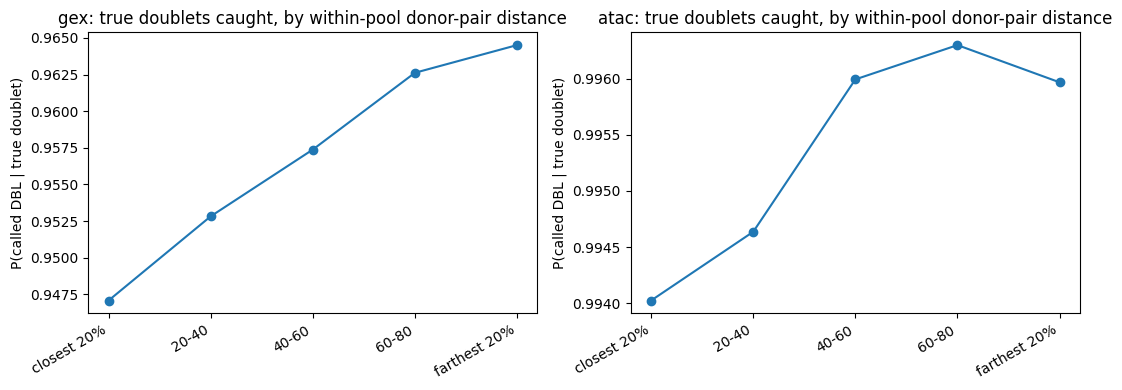

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, mod in enumerate(['gex', 'atac']):
    g = within[within['modality'] == mod]
    axes[i].plot(range(len(g)), g['called_dbl'], 'o-')
    axes[i].set_xticks(range(len(g))); axes[i].set_xticklabels(g['q'], rotation=30, ha='right')
    axes[i].set_title(f'{mod}: true doublets caught, by within-pool donor-pair distance')
    axes[i].set_ylabel('P(called DBL | true doublet)')
plt.tight_layout()
plt.show()

In [11]:
### AMBIENT-STRATIFIED on the donor margin. RESULTS.md section 4 says the design benefit fades
### with ambient RNA -- that was measured on ll_gap (the doublet margin). on sng_gap it does not.
called = x[x['is_true_singlet'] & x['called_singlet']].copy()
bins = [0, .1, .2, .3, .4, 1.0]
labs = ['0-10%', '10-20%', '20-30%', '30-40%', '>=40%']
called['amb'] = pd.cut(called['ambient_frac'], bins, labels=labs)
sng2 = sng.copy()
sng2['amb'] = pd.cut(sng2['ambient_frac'], bins, labels=labs)
amb_tab = []
for mod in ['gex', 'atac']:
    for ab in labs:
        cc = called[(called['modality'] == mod) & (called['amb'] == ab) & (called['grp'] == 'ordinary')]
        ss = sng2[(sng2['modality'] == mod) & (sng2['amb'] == ab) & (sng2['grp'] == 'ordinary')]
        if len(cc) < 5000:
            continue
        pp = cc.groupby('pool').agg(n=('donor_correct', 'size'), sng_gap=('sng_gap', 'mean'),
                                    acc=('donor_correct', 'mean'), mean_dist=('mean_dist', 'first'))
        pp['p_sng'] = ss.groupby('pool')['called_singlet'].mean()
        pp = pp[pp['n'] >= 200]
        if len(pp) < 20:
            continue
        row = dict(modality=mod, ambient=ab, n_pools=len(pp), n_droplets=len(cc),
                   sng_gap=pp['sng_gap'].mean())
        for tgt in ['sng_gap', 'acc', 'p_sng']:
            row[f'rho_{tgt}'], row[f'p_{tgt}'] = spearmanr(pp['mean_dist'], pp[tgt])
        amb_tab.append(row)
amb_tab = pd.DataFrame(amb_tab)
print(amb_tab.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

/tmp/ipykernel_119351/289641512.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  row[f'rho_{tgt}'], row[f'p_{tgt}'] = spearmanr(pp['mean_dist'], pp[tgt])
/tmp/ipykernel_119351/289641512.py:25: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  row[f'rho_{tgt}'], row[f'p_{tgt}'] = spearmanr(pp['mean_dist'], pp[tgt])


modality ambient  n_pools  n_droplets  sng_gap  rho_sng_gap  p_sng_gap  rho_acc  p_acc  rho_p_sng  p_p_sng
     gex   0-10%      105      192051  80.7688       0.7120     0.0000  -0.0099 0.9203     0.4873   0.0000
     gex  10-20%      105      275540  72.7355       0.7206     0.0000   0.3716 0.0001     0.4323   0.0000
     gex  20-30%      105      171881  68.9898       0.7210     0.0000   0.1383 0.1593     0.1227   0.2124
     gex  30-40%      105       62338  58.5901       0.7092     0.0000   0.2659 0.0061    -0.3381   0.0004
    atac   0-10%      105      190568 199.0591       0.7295     0.0000      NaN    NaN     0.1731   0.0774
    atac  10-20%      105      286219 186.0123       0.7366     0.0000   0.0377 0.7026     0.4719   0.0000
    atac  20-30%      105      196281 166.3694       0.7182     0.0000  -0.2146 0.0279     0.5689   0.0000
    atac  30-40%      105       88075 149.5197       0.7269     0.0000      NaN    NaN     0.3628   0.0001


In [12]:
### FAMILY POOLS, ancestry-matched. the family arms are EUR_only / EUR_AFR, so comparing them
### to the all-universe ordinary mean confounds relatedness with ancestry -- that inflated the
### penalty to 3.4x in an earlier pass.
def label(r):
    if r['strategy'] == 'adversarial_family':
        return 'family EUR_only'
    if r['strategy'] == 'adversarial_family_mixed':
        return 'family EUR_AFR'
    if r['strategy'] == 'adversarial_mindist':
        return 'adv_mindist (all univ)'
    return f"ordinary {r['universe']}"
x['g2'] = x.apply(label, axis=1)

rows = []
s = x[(x['modality'] == 'gex') & x['is_true_singlet']]
cc = s[s['called_singlet']]
for g in ['ordinary EUR_only', 'family EUR_only', 'ordinary EUR_AFR', 'family EUR_AFR',
          'ordinary AFR_only', 'ordinary all_5', 'adv_mindist (all univ)']:
    ss, c2 = s[s['g2'] == g], cc[cc['g2'] == g]
    if len(ss) == 0:
        continue
    rows.append(dict(group=g, pools=ss['pool'].nunique(), min_dist=ss['min_dist'].mean(),
                     mean_dist=ss['mean_dist'].mean(), sng_gap=c2['sng_gap'].mean(),
                     wrong_donor_per10k=(1 - c2['donor_correct'].mean()) * 10000,
                     lost_to_DBL_per10k=(1 - ss['called_singlet'].mean()) * 10000))
ancestry_matched = pd.DataFrame(rows)
print(ancestry_matched.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

                 group  pools  min_dist  mean_dist  sng_gap  wrong_donor_per10k  lost_to_DBL_per10k
     ordinary EUR_only     12    106.85     111.50    66.69               11.24             1578.90
       family EUR_only      3     74.89     102.14    45.90               32.77             1710.91
      ordinary EUR_AFR     12    107.01     119.62    78.02                6.95             1562.02
        family EUR_AFR      3     74.89     108.37    51.17               26.04             1780.06
     ordinary AFR_only     11    108.15     116.75    78.48                6.22             1703.69
        ordinary all_5     12    110.50     122.38    79.56                5.60             1549.47
adv_mindist (all univ)     17     95.44      99.59    65.86               11.98             1633.24


In [13]:
### are the family pools' donor-ID errors ON the related donors? derive relatedness from the
### 1000G pedigree rather than hardcoding one family -- the three reps are three DIFFERENT
### CEPH pedigrees (1420, 1463, 1362), each a couple plus all four of their parents, so 6/8
### donors have a first-degree relative in-pool and the other 2 are unrelated fill.
ped = pd.read_csv('/u/project/cluo/terencew/demux_benchmark/pool_design/csv/1000G/meta/'
                  '20130606_g1k_3202_samples_ped_population.txt', sep=r'\s+')
first = {}
for _, r in ped.iterrows():
    for p in (r['FatherID'], r['MotherID']):
        if str(p) != '0':
            first.setdefault(str(r['SampleID']), set()).add(str(p))
            first.setdefault(str(p), set()).add(str(r['SampleID']))
bypar = {}
for _, r in ped.iterrows():
    if str(r['FatherID']) != '0' and str(r['MotherID']) != '0':
        bypar.setdefault((r['FatherID'], r['MotherID']), []).append(str(r['SampleID']))
for kids in bypar.values():
    for a in kids:
        for b in kids:
            if a != b:
                first.setdefault(a, set()).add(b)

fam = x[(x['grp'] == 'family') & x['is_true_singlet'] & x['called_singlet']].copy()
pool_rel = {}
for p in fam['pool'].unique():
    donors = [l.strip() for l in open(f'{projdir}/txt/donors/{p}.txt') if l.strip()]
    pool_rel[p] = {d for d in donors if first.get(d, set()) & set(donors)}
    print(f'{p}: {len(pool_rel[p])}/{len(donors)} donors have a first-degree relative in-pool')
fam['has_rel'] = [d in pool_rel[p] for p, d in zip(fam['pool'], fam['true_donor'])]

EUR_only__adversarial_family__rep1: 6/8 donors have a first-degree relative in-pool
EUR_only__adversarial_family__rep2: 6/8 donors have a first-degree relative in-pool
EUR_only__adversarial_family__rep3: 6/8 donors have a first-degree relative in-pool
EUR_AFR__adversarial_family_mixed__rep1: 6/8 donors have a first-degree relative in-pool
EUR_AFR__adversarial_family_mixed__rep2: 6/8 donors have a first-degree relative in-pool
EUR_AFR__adversarial_family_mixed__rep3: 6/8 donors have a first-degree relative in-pool


In [14]:
fam_loc = []
for mod in ['gex', 'atac']:
    t = fam[fam['modality'] == mod]
    g = t.groupby('has_rel').agg(n=('donor_correct', 'size'), acc=('donor_correct', 'mean'),
                                 sng_gap=('sng_gap', 'mean'))
    g['err_per_10k'] = (1 - g['acc']) * 10000
    g['modality'] = mod
    fam_loc.append(g.reset_index())
    print(f'--- {mod} ---')
    print(g.round(4).to_string())
    wrong = t[~t['donor_correct']]
    to_rel = wrong.apply(lambda r: r['called_donor'] in first.get(r['true_donor'], set()), axis=1)
    print(f'   wrong calls n={len(wrong)}; called donor IS a first-degree relative: '
          f'{int(to_rel.sum())} ({to_rel.mean() * 100:.1f}%)')
fam_loc = pd.concat(fam_loc, ignore_index=True)

--- gex ---
             n     acc  sng_gap  err_per_10k modality
has_rel                                              
False    10026  0.9992  77.3390       7.9793      gex
True     30086  0.9963  38.9213      36.5619      gex
   wrong calls n=118; called donor IS a first-degree relative: 74 (62.7%)
--- atac ---
             n     acc   sng_gap  err_per_10k modality
has_rel                                               
False    11032  0.9999  196.3423       0.9065     atac
True     33051  0.9998   91.7926       1.8154     atac
   wrong calls n=7; called donor IS a first-degree relative: 4 (57.1%)


In [15]:
### full cell accounting per 10,000 LOADED droplets -- every way a droplet can go bad, in one
### place, so the relatedness cost can be read as cells rather than as a correlation
acct = []
for g in ['ordinary EUR_only', 'family EUR_only', 'adv_mindist (all univ)']:
    t = x[(x['modality'] == 'gex') & (x['g2'] == g)]
    sg, db = t[t['is_true_singlet']], t[~t['is_true_singlet']]
    n = len(sg) + len(db)
    row = dict(group=g,
               singlets_called_DBL=(~sg['called_singlet']).sum() / n * 10000,
               wrong_donor=(sg['called_singlet'] & ~sg['donor_correct']).sum() / n * 10000,
               doublets_missed=(db['droplet_type'] != 'DBL').sum() / n * 10000)
    row['total_bad'] = row['singlets_called_DBL'] + row['wrong_donor'] + row['doublets_missed']
    acct.append(row)
acct = pd.DataFrame(acct)
print(acct.to_string(index=False, float_format=lambda v: f'{v:.1f}'))

                 group  singlets_called_DBL  wrong_donor  doublets_missed  total_bad
     ordinary EUR_only               1421.0          8.5             47.5     1477.0
       family EUR_only               1539.8         24.4             60.4     1624.6
adv_mindist (all univ)               1469.9          9.0             51.2     1530.2


In [16]:
outdir = f'{projdir}/csv/ambisim'
within.to_csv(f'{outdir}/doublet_pair_distance.csv', sep='\t', index=False)
amb_tab.to_csv(f'{outdir}/ambient_stratified_sng_gap.csv', sep='\t', index=False)
ancestry_matched.to_csv(f'{outdir}/family_ancestry_matched.csv', sep='\t', index=False)
fam_loc.to_csv(f'{outdir}/family_error_localization.csv', sep='\t', index=False)
acct.to_csv(f'{outdir}/cell_accounting_per10k.csv', sep='\t', index=False)

In [17]:
!date

Sat Sep 19 01:03:12 PDT 2026
